# Adversarial ML Attack Lab

Implementation and comparison of three classic **adversarial attacks** against a CNN
trained on CIFAR-10, plus **adversarial training** as a defence.

| Attack | Family | Steps | Norm | Reference |
|---|---|---|---|---|
| **FGSM** | gradient-sign | 1 | L∞ | Goodfellow et al. 2014 |
| **PGD**  | iterative FGSM | k | L∞ | Madry et al. 2017 |
| **DeepFool** | linearised boundary | k | L2 | Moosavi-Dezfooli et al. 2016 |

**Defence:** PGD adversarial training (Madry et al. 2017).

> All experiments run on CPU. Times reported below assume a modern x86 CPU.


## 1. Setup

Import modules, fix seeds, pick device.

In [1]:
import warnings
warnings.filterwarnings("ignore")  # silence library warnings (avoids leaking local paths in stderr)

import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, Subset
from typing import Callable
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch: {torch.__version__}")


Using device: cpu
PyTorch: 2.11.0+cpu


### 1.1 Model — compact CNN for CIFAR-10


In [2]:
class SmallCNN(nn.Module):
    """Compact CNN for CIFAR-10.

    Three Conv-BN-ReLU-MaxPool blocks followed by two FC layers.
    Input:  (B, 3, 32, 32)
    Output: (B, num_classes) logits
    """

    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.pool(F.relu(self.bn1(self.conv1(x))))   # 32 -> 16
        x = self.pool(F.relu(self.bn2(self.conv2(x))))   # 16 -> 8
        x = self.pool(F.relu(self.bn3(self.conv3(x))))   # 8  -> 4
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)


### 1.2 Training & evaluation loops


In [3]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total, correct, running_loss = 0, 0, 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total, correct = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        correct += (model(x).argmax(1) == y).sum().item()
        total += x.size(0)
    return correct / total


def train(model, train_loader, test_loader, device, epochs=8, lr=1e-3):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = []
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        test_acc = evaluate(model, test_loader, device)
        history.append(
            {"epoch": epoch, "train_loss": train_loss, "train_acc": train_acc, "test_acc": test_acc}
        )
        print(
            f"Epoch {epoch:2d} | train_loss {train_loss:.4f} | "
            f"train_acc {train_acc:.4f} | test_acc {test_acc:.4f}"
        )
    return history


### 1.3 Adversarial attacks — FGSM, PGD, DeepFool


In [4]:
def fgsm_attack(model, x, y, epsilon, clip_min=0.0, clip_max=1.0):
    """Fast Gradient Sign Method (single-step, L_inf).

    x_adv = clip( x + epsilon * sign( grad_x L(theta, x, y) ) )
    """
    was_training = model.training
    model.eval()

    x_adv = x.clone().detach().requires_grad_(True)
    logits = model(x_adv)
    loss = F.cross_entropy(logits, y)
    grad = torch.autograd.grad(loss, x_adv)[0]
    x_adv = x_adv.detach() + epsilon * grad.sign()
    x_adv = x_adv.clamp(clip_min, clip_max)

    if was_training:
        model.train()
    return x_adv


def pgd_attack(model, x, y, epsilon, alpha, steps,
               clip_min=0.0, clip_max=1.0, random_start=True):
    """Projected Gradient Descent (iterative FGSM, L_inf bounded)."""
    was_training = model.training
    model.eval()

    x_orig = x.clone().detach()
    if random_start:
        x_adv = x_orig + torch.empty_like(x_orig).uniform_(-epsilon, epsilon)
        x_adv = x_adv.clamp(clip_min, clip_max).detach()
    else:
        x_adv = x_orig.clone().detach()

    for _ in range(steps):
        x_adv.requires_grad_(True)
        logits = model(x_adv)
        loss = F.cross_entropy(logits, y)
        grad = torch.autograd.grad(loss, x_adv)[0]
        x_adv = x_adv.detach() + alpha * grad.sign()
        delta = (x_adv - x_orig).clamp(-epsilon, epsilon)
        x_adv = (x_orig + delta).clamp(clip_min, clip_max).detach()

    if was_training:
        model.train()
    return x_adv


def deepfool_attack(model, x, num_classes=10, max_iter=50, overshoot=0.02,
                    clip_min=0.0, clip_max=1.0):
    """DeepFool (untargeted, multi-class). Per-sample; slower than FGSM/PGD."""
    was_training = model.training
    model.eval()

    x_adv = x.clone().detach()
    batch_size = x.size(0)

    with torch.no_grad():
        original_preds = model(x).argmax(dim=1)

    for i in range(batch_size):
        xi = x[i:i + 1].clone().detach()
        ki = original_preds[i].item()

        r_total = torch.zeros_like(xi)
        for _ in range(max_iter):
            xi_pert = (xi + r_total).detach().requires_grad_(True)
            logits = model(xi_pert)[0]
            if logits.argmax().item() != ki:
                break

            grad_orig = torch.autograd.grad(logits[ki], xi_pert, retain_graph=True)[0]

            min_dist = float("inf")
            best_w = None
            best_f = None
            for k in range(num_classes):
                if k == ki:
                    continue
                grad_k = torch.autograd.grad(logits[k], xi_pert, retain_graph=True)[0]
                w_k = (grad_k - grad_orig).detach()
                f_k = (logits[k] - logits[ki]).detach()
                w_norm = w_k.flatten().norm().item() + 1e-10
                dist_k = abs(f_k.item()) / w_norm
                if dist_k < min_dist:
                    min_dist = dist_k
                    best_w = w_k
                    best_f = f_k

            r_i = (abs(best_f.item()) + 1e-4) / (best_w.flatten().norm().item() ** 2 + 1e-10) * best_w
            r_total = r_total + r_i.detach()

        x_adv[i] = (xi + (1 + overshoot) * r_total).clamp(clip_min, clip_max)

    if was_training:
        model.train()
    return x_adv.detach()


### 1.4 Defence — PGD adversarial training


In [5]:
def adversarial_train_epoch(model, loader, optimizer, device, epsilon, alpha, steps):
    """One epoch of PGD-based adversarial training."""
    criterion = nn.CrossEntropyLoss()
    total, correct, running_loss = 0, 0, 0.0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        x_adv = pgd_attack(model, x, y, epsilon=epsilon, alpha=alpha, steps=steps)

        model.train()
        optimizer.zero_grad()
        logits = model(x_adv)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)

    return running_loss / total, correct / total


def adversarial_train(model, train_loader, test_loader, device,
                      epochs=5, lr=1e-3, epsilon=8/255, alpha=2/255, steps=5):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = []

    for epoch in range(1, epochs + 1):
        adv_loss, adv_acc = adversarial_train_epoch(
            model, train_loader, optimizer, device, epsilon, alpha, steps
        )

        model.eval()
        total, correct = 0, 0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                correct += (model(x).argmax(1) == y).sum().item()
                total += x.size(0)
        clean_acc = correct / total

        history.append({
            "epoch": epoch,
            "adv_train_loss": adv_loss,
            "adv_train_acc": adv_acc,
            "clean_test_acc": clean_acc,
        })
        print(
            f"AdvEpoch {epoch:2d} | adv_loss {adv_loss:.4f} | "
            f"adv_train_acc {adv_acc:.4f} | clean_test_acc {clean_acc:.4f}"
        )
    return history


### 1.5 Evaluation metrics & visualization


In [6]:
CIFAR10_CLASSES = (
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
)


def attack_success_rate(model, loader, attack_fn, device,
                        only_correct=True, max_batches=None, **attack_kwargs):
    """Evasion metrics over a dataloader.

    Returns dict with: clean_acc, adv_acc, evasion_rate, mean_l_inf, mean_l2.
    """
    model.eval()
    clean_correct = 0
    adv_correct = 0
    fooled = 0
    correct_originally = 0
    total = 0
    sum_linf = 0.0
    sum_l2 = 0.0

    for batch_idx, (x, y) in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break
        x, y = x.to(device), y.to(device)
        with torch.no_grad():
            clean_pred = model(x).argmax(1)
        clean_correct += (clean_pred == y).sum().item()

        if only_correct:
            mask = clean_pred == y
            if mask.sum().item() == 0:
                total += x.size(0)
                continue
            x_attack, y_attack = x[mask], y[mask]
        else:
            x_attack, y_attack = x, y

        with torch.enable_grad():
            try:
                x_adv = attack_fn(model, x_attack, y_attack, **attack_kwargs)
            except TypeError:
                x_adv = attack_fn(model, x_attack, **attack_kwargs)

        with torch.no_grad():
            adv_pred = model(x_adv).argmax(1)

        if only_correct:
            full_adv_pred = clean_pred.clone()
            full_adv_pred[mask] = adv_pred
            adv_correct += (full_adv_pred == y).sum().item()
            fooled += (adv_pred != y_attack).sum().item()
            correct_originally += mask.sum().item()
            delta = (x_adv - x_attack).view(x_attack.size(0), -1)
        else:
            adv_correct += (adv_pred == y).sum().item()
            fooled += (adv_pred != y).sum().item()
            correct_originally += x.size(0)
            delta = (x_adv - x).view(x.size(0), -1)

        sum_linf += delta.abs().max(dim=1).values.sum().item()
        sum_l2 += delta.norm(p=2, dim=1).sum().item()

        total += x.size(0)

    return {
        "clean_acc": clean_correct / total if total > 0 else 0.0,
        "adv_acc": adv_correct / total if total > 0 else 0.0,
        "evasion_rate": fooled / correct_originally if correct_originally > 0 else 0.0,
        "mean_l_inf": sum_linf / correct_originally if correct_originally > 0 else 0.0,
        "mean_l2": sum_l2 / correct_originally if correct_originally > 0 else 0.0,
        "n_samples": total,
        "n_correct_originally": correct_originally,
    }


def show_adversarial_examples(model, x, y, x_adv, classes=CIFAR10_CLASSES,
                              n=8, device=torch.device("cpu"),
                              title="Adversarial examples"):
    """Show clean / adversarial / perturbation triplets."""
    model.eval()
    with torch.no_grad():
        clean_pred = model(x.to(device)).argmax(1).cpu()
        adv_pred = model(x_adv.to(device)).argmax(1).cpu()

    n = min(n, x.size(0))
    fig, axes = plt.subplots(3, n, figsize=(2 * n, 6))
    if n == 1:
        axes = axes[:, None]

    for i in range(n):
        clean_img = x[i].permute(1, 2, 0).cpu().numpy()
        adv_img = x_adv[i].permute(1, 2, 0).cpu().numpy()
        delta = adv_img - clean_img
        rng = delta.max() - delta.min()
        delta_viz = (delta - delta.min()) / (rng + 1e-10)

        axes[0, i].imshow(np.clip(clean_img, 0, 1))
        axes[0, i].set_title(
            f"clean -> {classes[clean_pred[i]]}",
            fontsize=9,
            color="green" if clean_pred[i] == y[i] else "orange",
        )
        axes[0, i].axis("off")

        axes[1, i].imshow(np.clip(adv_img, 0, 1))
        axes[1, i].set_title(
            f"adv -> {classes[adv_pred[i]]}",
            fontsize=9,
            color="red" if adv_pred[i] != y[i] else "green",
        )
        axes[1, i].axis("off")

        axes[2, i].imshow(delta_viz)
        axes[2, i].set_title("perturbation", fontsize=9)
        axes[2, i].axis("off")

    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    return fig


def plot_evasion_comparison(results, title="Attack evasion comparison"):
    """results: {attack_name: {epsilon_or_label: evasion_rate}}"""
    fig, ax = plt.subplots(figsize=(8, 5))
    for attack_name, rates in results.items():
        xs = list(rates.keys())
        ys = list(rates.values())
        ax.plot(xs, ys, marker="o", label=attack_name)
    ax.set_xlabel("epsilon (L_inf budget)")
    ax.set_ylabel("evasion rate")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()
    return fig


## 2. Dataset — CIFAR-10

50 000 training / 10 000 test images of 32×32 RGB pixels across 10 classes.
Images are kept in `[0, 1]` (no normalisation) so attack budgets (`epsilon`)
are directly interpretable as pixel fractions, e.g. `epsilon = 8/255 ≈ 0.031`.

In [7]:
transform = T.ToTensor()  # [0,1] range, no normalisation

trainset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform,
)
testset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform,
)

train_loader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=0)
test_loader = DataLoader(testset, batch_size=256, shuffle=False, num_workers=0)

print(f"Train: {len(trainset)} samples | Test: {len(testset)} samples")
print(f"Classes: {CIFAR10_CLASSES}")

100%|██████████| 170M/170M [00:06<00:00, 24.4MB/s] 


Train: 50000 samples | Test: 10000 samples
Classes: ('airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


## 3. Baseline CNN

A compact 3-block ConvNet (~600k params). On CPU, ~40 s/epoch; 8 epochs gets to
~70–75 % test accuracy — sufficient as a victim model for the attacks below.

In [8]:
model = SmallCNN(num_classes=10)
n_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {n_params:,}")
print(model)

Parameters: 620,810
SmallCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)


In [9]:
EPOCHS = 8  # ~5 min on a modern CPU
history = train(model, train_loader, test_loader, device, epochs=EPOCHS, lr=1e-3)
torch.save(model.state_dict(), "./baseline.pt")
print("Saved baseline weights to results/baseline.pt")

Epoch  1 | train_loss 1.3864 | train_acc 0.4956 | test_acc 0.6023
Epoch  2 | train_loss 1.0465 | train_acc 0.6307 | test_acc 0.6554
Epoch  3 | train_loss 0.9051 | train_acc 0.6828 | test_acc 0.6953
Epoch  4 | train_loss 0.8210 | train_acc 0.7123 | test_acc 0.6895
Epoch  5 | train_loss 0.7589 | train_acc 0.7378 | test_acc 0.6730
Epoch  6 | train_loss 0.6980 | train_acc 0.7568 | test_acc 0.6902
Epoch  7 | train_loss 0.6437 | train_acc 0.7774 | test_acc 0.7557
Epoch  8 | train_loss 0.6011 | train_acc 0.7910 | test_acc 0.7241
Saved baseline weights to results/baseline.pt


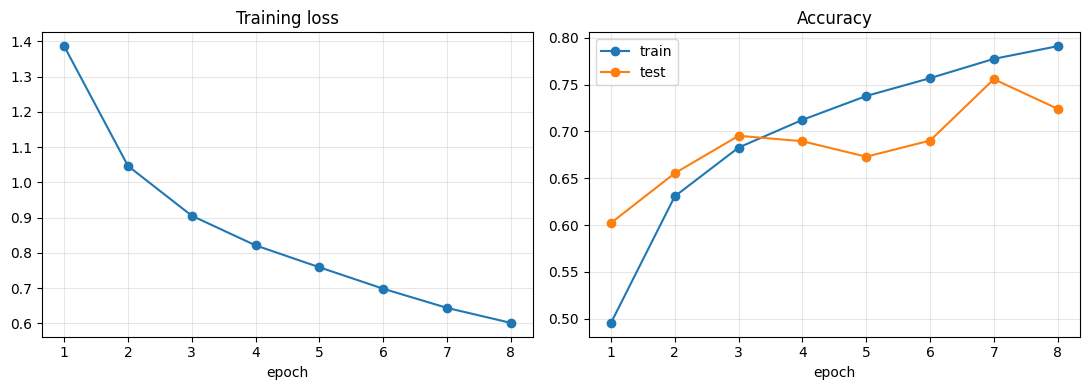

In [10]:
epochs = [h["epoch"] for h in history]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(epochs, [h["train_loss"] for h in history], marker="o")
ax[0].set_title("Training loss"); ax[0].set_xlabel("epoch"); ax[0].grid(alpha=0.3)
ax[1].plot(epochs, [h["train_acc"] for h in history], marker="o", label="train")
ax[1].plot(epochs, [h["test_acc"]  for h in history], marker="o", label="test")
ax[1].set_title("Accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Adversarial attacks

For each attack we measure:
- **clean accuracy** — baseline on unperturbed inputs
- **adversarial accuracy** — accuracy after the attack
- **evasion rate** — fraction of *originally-correct* samples flipped to a wrong class
- **mean L∞ / L2** — average perturbation magnitude

To keep the notebook fast on CPU we evaluate on the **first 10 batches**
(`max_batches=10` ≈ 2 560 test samples).

### 4.1 FGSM — Fast Gradient Sign Method

$x_{adv} = \text{clip}\left(x + \epsilon \cdot \text{sign}\!\left(\nabla_x \mathcal{L}(\theta, x, y)\right)\right)$

Single step. Cheap to compute, weakest of the three. We sweep `epsilon`.

In [11]:
EPSILONS = [2/255, 4/255, 8/255, 16/255]
fgsm_results = {}
for eps in EPSILONS:
    r = attack_success_rate(
        model, test_loader, fgsm_attack, device,
        epsilon=eps, max_batches=10,
    )
    fgsm_results[eps] = r
    print(f"FGSM eps={eps:.4f} | clean_acc={r['clean_acc']:.3f} "
          f"adv_acc={r['adv_acc']:.3f} evasion={r['evasion_rate']:.3f} "
          f"L_inf={r['mean_l_inf']:.4f}")

FGSM eps=0.0078 | clean_acc=0.721 adv_acc=0.279 evasion=0.613 L_inf=0.0078
FGSM eps=0.0157 | clean_acc=0.721 adv_acc=0.110 evasion=0.848 L_inf=0.0157
FGSM eps=0.0314 | clean_acc=0.721 adv_acc=0.024 evasion=0.966 L_inf=0.0314
FGSM eps=0.0627 | clean_acc=0.721 adv_acc=0.011 evasion=0.985 L_inf=0.0627


### 4.2 PGD — Projected Gradient Descent

Iterative FGSM with random start and projection back onto the L∞ ball
around the input after each step. Strongest L∞ first-order attack.

Standard CIFAR-10 hyperparameters: `epsilon=8/255`, `alpha=2/255`, `steps=10`.

In [12]:
pgd_results = {}
for eps in EPSILONS:
    alpha = eps / 4  # standard scaling
    r = attack_success_rate(
        model, test_loader, pgd_attack, device,
        epsilon=eps, alpha=alpha, steps=10, max_batches=10,
    )
    pgd_results[eps] = r
    print(f"PGD  eps={eps:.4f} | adv_acc={r['adv_acc']:.3f} "
          f"evasion={r['evasion_rate']:.3f} L_inf={r['mean_l_inf']:.4f}")

PGD  eps=0.0078 | adv_acc=0.182 evasion=0.748 L_inf=0.0078
PGD  eps=0.0157 | adv_acc=0.016 evasion=0.977 L_inf=0.0157
PGD  eps=0.0314 | adv_acc=0.000 evasion=1.000 L_inf=0.0314
PGD  eps=0.0627 | adv_acc=0.000 evasion=1.000 L_inf=0.0627


### 4.3 DeepFool — minimum-norm perturbation

Iteratively perturbs each sample by the smallest amount needed to cross the
**nearest** decision boundary (linear approximation). Yields the smallest L2
perturbation of the three, but is slower (per-sample loop).

We evaluate on a single batch of 128 samples for tractability on CPU.

In [13]:
# DeepFool: untargeted, no epsilon — measure mean perturbation magnitude.
small_loader = DataLoader(Subset(testset, list(range(128))), batch_size=128)
deepfool_r = attack_success_rate(
    model, small_loader, deepfool_attack, device,
    num_classes=10, max_iter=50, overshoot=0.02,
)
print(f"DeepFool | clean_acc={deepfool_r['clean_acc']:.3f} "
      f"adv_acc={deepfool_r['adv_acc']:.3f} evasion={deepfool_r['evasion_rate']:.3f}")
print(f"         | mean L_inf={deepfool_r['mean_l_inf']:.4f} "
      f"mean L2={deepfool_r['mean_l2']:.4f}")

DeepFool | clean_acc=0.664 adv_acc=0.055 evasion=0.918
         | mean L_inf=0.0267 mean L2=0.2641


## 5. Comparison

Evasion rate as a function of `epsilon` for FGSM vs PGD (both L∞-bounded).
DeepFool is plotted as a single point at its mean L∞ since it is not
budget-parameterised.

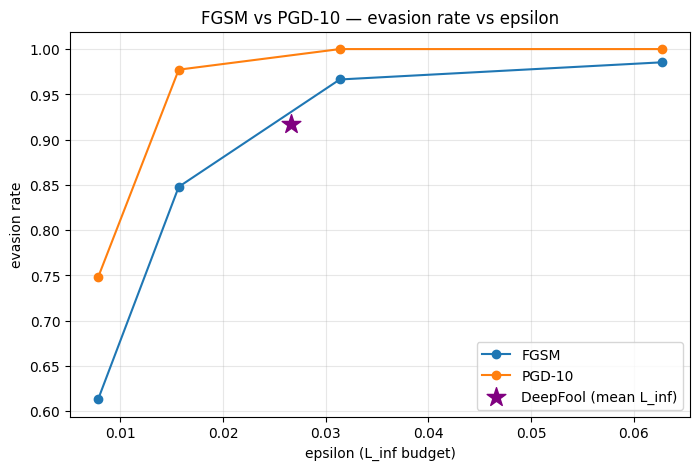

In [14]:
plot_data = {
    "FGSM": {eps: fgsm_results[eps]["evasion_rate"] for eps in EPSILONS},
    "PGD-10": {eps: pgd_results[eps]["evasion_rate"] for eps in EPSILONS},
}
fig = plot_evasion_comparison(plot_data, title="FGSM vs PGD-10 — evasion rate vs epsilon")
ax = fig.axes[0]
ax.scatter([deepfool_r["mean_l_inf"]], [deepfool_r["evasion_rate"]],
           marker="*", s=200, color="purple", label="DeepFool (mean L_inf)", zorder=5)
ax.legend()
plt.show()

## 6. Visualising adversarial examples

A side-by-side view of clean / adversarial / perturbation for a handful of
test samples at `epsilon = 8/255`.

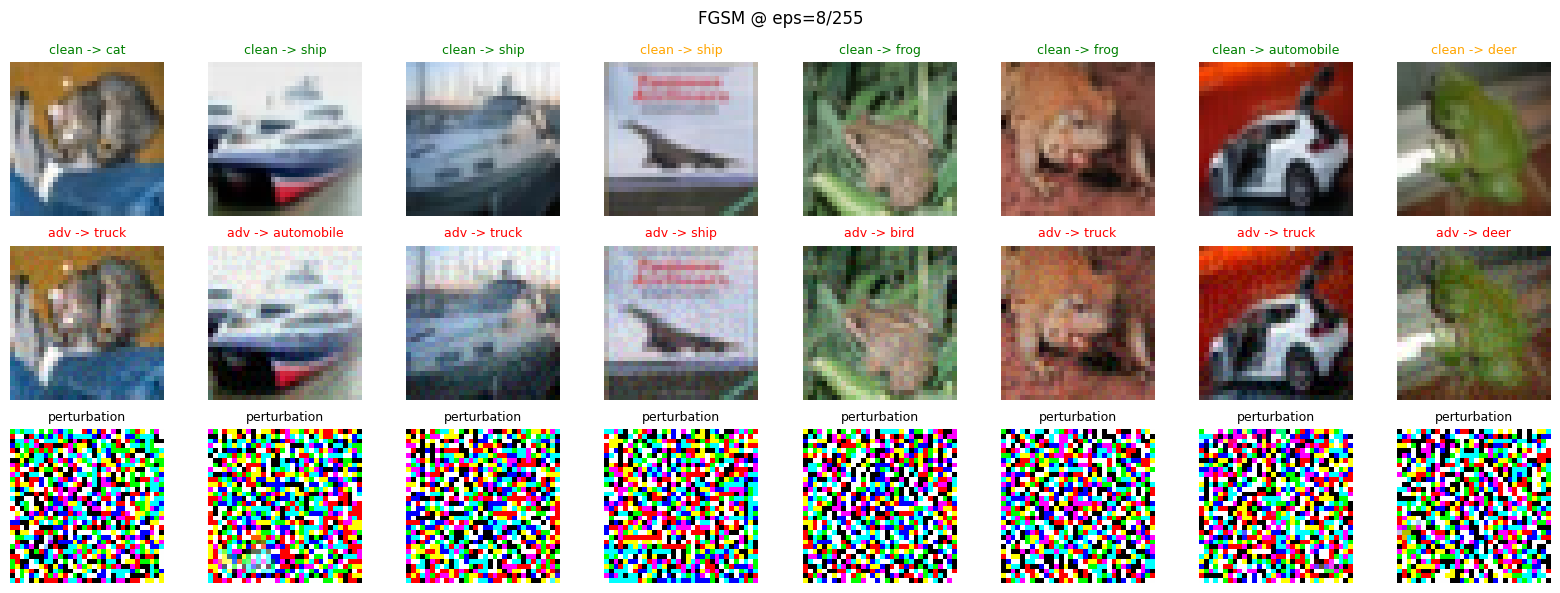

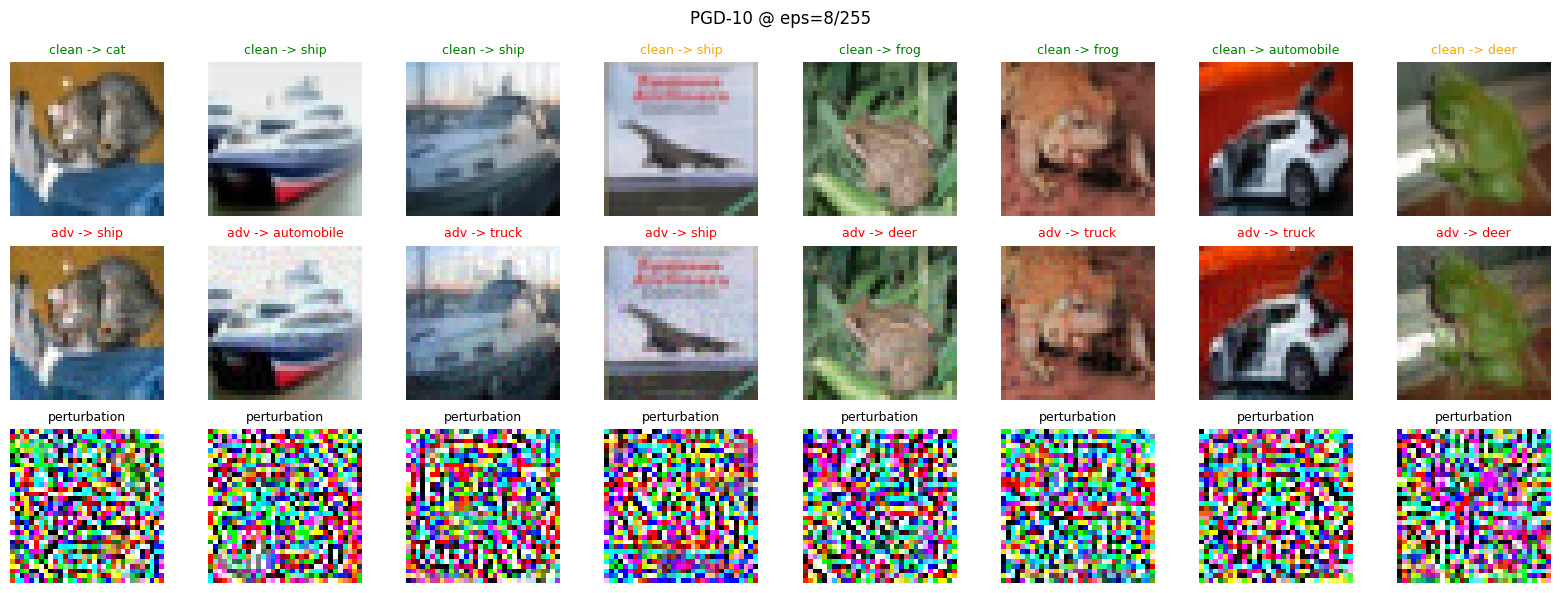

In [15]:
x_batch, y_batch = next(iter(test_loader))
x_batch, y_batch = x_batch[:8].to(device), y_batch[:8].to(device)

x_fgsm = fgsm_attack(model, x_batch, y_batch, epsilon=8/255)
x_pgd  = pgd_attack(model, x_batch, y_batch, epsilon=8/255, alpha=2/255, steps=10)

show_adversarial_examples(model, x_batch, y_batch, x_fgsm,
                          title="FGSM @ eps=8/255")
plt.show()
show_adversarial_examples(model, x_batch, y_batch, x_pgd,
                          title="PGD-10 @ eps=8/255")
plt.show()

## 7. Defence — adversarial training

Re-train the network on PGD-perturbed batches. This trades clean accuracy for
substantially better robustness to bounded L∞ attacks.

**Cost:** each training step is now `(1 + PGD_steps)` forward/backward passes.
We use `steps=5, epsilon=8/255` and **12 epochs**, warm-started from the baseline
weights — total ~20 min on a modern CPU.

In [16]:
model_robust = SmallCNN(num_classes=10)
model_robust.load_state_dict(torch.load("./baseline.pt", map_location=device))
# warm-start from baseline weights for faster convergence

ADV_EPOCHS = 12
adv_history = adversarial_train(
    model_robust, train_loader, test_loader, device,
    epochs=ADV_EPOCHS, lr=5e-4, epsilon=8/255, alpha=2/255, steps=5,
)
torch.save(model_robust.state_dict(), "./robust.pt")

AdvEpoch  1 | adv_loss 2.3551 | adv_train_acc 0.1602 | clean_test_acc 0.4143
AdvEpoch  2 | adv_loss 2.0641 | adv_train_acc 0.2363 | clean_test_acc 0.4596
AdvEpoch  3 | adv_loss 1.9698 | adv_train_acc 0.2735 | clean_test_acc 0.4947
AdvEpoch  4 | adv_loss 1.9056 | adv_train_acc 0.2992 | clean_test_acc 0.5178
AdvEpoch  5 | adv_loss 1.8630 | adv_train_acc 0.3107 | clean_test_acc 0.5323
AdvEpoch  6 | adv_loss 1.8287 | adv_train_acc 0.3243 | clean_test_acc 0.5441
AdvEpoch  7 | adv_loss 1.8062 | adv_train_acc 0.3317 | clean_test_acc 0.5483
AdvEpoch  8 | adv_loss 1.7829 | adv_train_acc 0.3382 | clean_test_acc 0.5696
AdvEpoch  9 | adv_loss 1.7651 | adv_train_acc 0.3439 | clean_test_acc 0.5740
AdvEpoch 10 | adv_loss 1.7494 | adv_train_acc 0.3494 | clean_test_acc 0.5743
AdvEpoch 11 | adv_loss 1.7370 | adv_train_acc 0.3541 | clean_test_acc 0.5942
AdvEpoch 12 | adv_loss 1.7230 | adv_train_acc 0.3608 | clean_test_acc 0.5899


### 7.1 Robustness comparison

Same PGD-10 attack as before, applied to both the baseline and the robust model.

In [17]:
def compare(model_a, model_b, eps):
    ra = attack_success_rate(model_a, test_loader, pgd_attack, device,
                             epsilon=eps, alpha=eps/4, steps=10, max_batches=10)
    rb = attack_success_rate(model_b, test_loader, pgd_attack, device,
                             epsilon=eps, alpha=eps/4, steps=10, max_batches=10)
    return ra, rb

for eps in EPSILONS:
    ra, rb = compare(model, model_robust, eps)
    print(f"eps={eps:.4f} | baseline adv_acc={ra['adv_acc']:.3f} "
          f"| robust adv_acc={rb['adv_acc']:.3f} "
          f"| Δ={(rb['adv_acc'] - ra['adv_acc']):+.3f}")

eps=0.0078 | baseline adv_acc=0.179 | robust adv_acc=0.529 | Δ=+0.350
eps=0.0157 | baseline adv_acc=0.016 | robust adv_acc=0.461 | Δ=+0.446
eps=0.0314 | baseline adv_acc=0.000 | robust adv_acc=0.331 | Δ=+0.331
eps=0.0627 | baseline adv_acc=0.000 | robust adv_acc=0.119 | Δ=+0.119


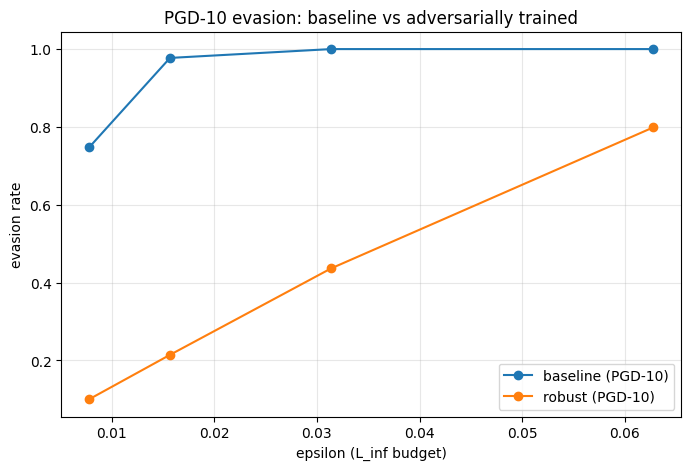

In [18]:
baseline_rates = {eps: pgd_results[eps]["evasion_rate"] for eps in EPSILONS}
robust_rates = {}
for eps in EPSILONS:
    r = attack_success_rate(model_robust, test_loader, pgd_attack, device,
                            epsilon=eps, alpha=eps/4, steps=10, max_batches=10)
    robust_rates[eps] = r["evasion_rate"]

fig = plot_evasion_comparison(
    {"baseline (PGD-10)": baseline_rates, "robust (PGD-10)": robust_rates},
    title="PGD-10 evasion: baseline vs adversarially trained",
)
plt.show()